In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_dir = Path("../data/results")
df = pd.concat(
    [
        pd.read_csv(results_dir / "sgd_mnist_dom_loss.csv"),
        pd.read_csv(results_dir / "sgd_mnist_bulk_loss.csv"),
    ]
)
df.head()

,Run,Run ID,metric,step,timestamp,value
0,mnist_mlp3__sgd__hessian_topk__dom,3ca9b88f502744f297ecb1fa1971f302,loss,1,1779021780324,1.143308
1,mnist_mlp3__sgd__hessian_topk__dom,3ca9b88f502744f297ecb1fa1971f302,loss,50,1779021789995,0.555628
2,mnist_mlp3__sgd__hessian_topk__dom,3ca9b88f502744f297ecb1fa1971f302,loss,100,1779021799812,0.465827
3,mnist_mlp3__sgd__hessian_topk__dom,3ca9b88f502744f297ecb1fa1971f302,loss,150,1779021809755,0.432845
4,mnist_mlp3__sgd__hessian_topk__dom,3ca9b88f502744f297ecb1fa1971f302,loss,250,1779021829470,0.408973


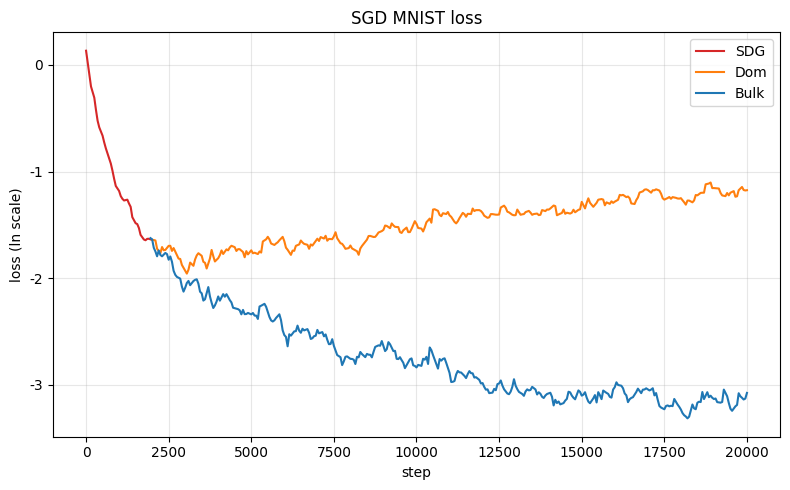

In [ ]:
SMOOTHING = 0.8


def ema_smooth(values, weight):
    out = np.empty_like(values, dtype=float)
    last = values[0]
    for i, v in enumerate(values):
        last = last * weight + (1 - weight) * v
        out[i] = last
    return out


curves = {}
for run, g in df.groupby("Run"):
    g = g.sort_values("step")
    kind = "Dom" if "dom" in run.lower() else "Bulk"
    curves[kind] = (g["step"].to_numpy(), ema_smooth(g["value"].to_numpy(), SMOOTHING))

dom_steps, dom_vals = curves["Dom"]
bulk_steps, bulk_vals = curves["Bulk"]

bulk_start = bulk_steps.min()
pre_mask = dom_steps < bulk_start

join = np.flatnonzero(~pre_mask)[:1]
sdg_mask = pre_mask.copy()
sdg_mask[join] = True

sdg = np.where(sdg_mask, dom_vals, np.nan)
dom_only = np.where(pre_mask, np.nan, dom_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dom_steps, sdg, label="SGD", color="tab:red")
ax.plot(dom_steps, dom_only, label="Dom", color="tab:orange")
ax.plot(bulk_steps, bulk_vals, label="Bulk", color="tab:blue")
ax.set_yscale("log", base=np.e)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{np.log(v):.0f}"))
ax.set_xlabel("step")
ax.set_ylabel("loss (ln scale)")
ax.set_title(f"SGD MNIST loss")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()

out_path = Path("../data/sgd_mnist_loss.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()